In [3]:
# Step 1: Robust CSV loading & numeric preparation for Factor Analysis
!pip install --quiet factor_analyzer pandas numpy openpyxl

import pandas as pd
import numpy as np
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from google.colab import files
import os

# --- Detect or upload CSV ---
uploaded_files = [f for f in os.listdir() if f.endswith('.csv')]
if len(uploaded_files) == 0:
    print("No CSV found. Please upload your dataset.")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
else:
    filename = uploaded_files[0]
print(f"Using file: {filename}")

# --- Load CSV safely ---
df = pd.read_csv(filename)
df.columns = [col.strip().replace(" ", "_") for col in df.columns]  # Clean column names
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)    # Trim strings

# --- Auto-map common Likert responses ---
likert_map = {'Strongly Agree':5, 'Agree':4, 'Neutral':3, 'Disagree':2, 'Strongly Disagree':1,
              'Yes':1, 'No':0}
df.replace(likert_map, inplace=True)

# --- Convert numeric-like text columns ---
for col in df.columns:
    if df[col].dtype == object:
        df[col] = pd.to_numeric(df[col], errors='ignore')

# --- Select numeric columns only ---
numeric_df = df.select_dtypes(include=[np.number])
print("Detected numeric columns:", list(numeric_df.columns))

# --- Drop rows with NA only in numeric columns ---
numeric_df_clean = numeric_df.dropna()

# --- Save snapshot ---
numeric_df_clean.to_csv('numeric_snapshot.csv', index=False)

# --- KMO and Bartlett's Test ---
kmo_all, kmo_model = calculate_kmo(numeric_df_clean)
chi_square_value, p_value = calculate_bartlett_sphericity(numeric_df_clean)

print("Overall KMO:", kmo_model)
print("Bartlett's Test p-value:", p_value)


Using file: Responses CSV FIle.csv
Detected numeric columns: ['Interest_in_the_Course', 'How_confident_are_you_in_understanding_engineering_subjects_this_semester?', 'Do_financial_problems_affect_your_studies?', 'Family_Support_for_Education', 'Level_of_Stress_or_Anxiety_Related_to_Studies', 'Do_you_feel_socially_isolated_or_left_out_in_college?', 'Motivation_to_Continue_Studies', 'Quality_of_Teaching_and_Learning_Resources', 'Availability_of_Academic_Support_(e.g.,_mentoring,_tutoring)', 'Satisfaction_with_College_Administration_Support']
Overall KMO: 0.6900642033812325
Bartlett's Test p-value: 2.7130224521264434e-13


/tmp/ipython-input-4003900398.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)    # Trim strings
/tmp/ipython-input-4003900398.py:33: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


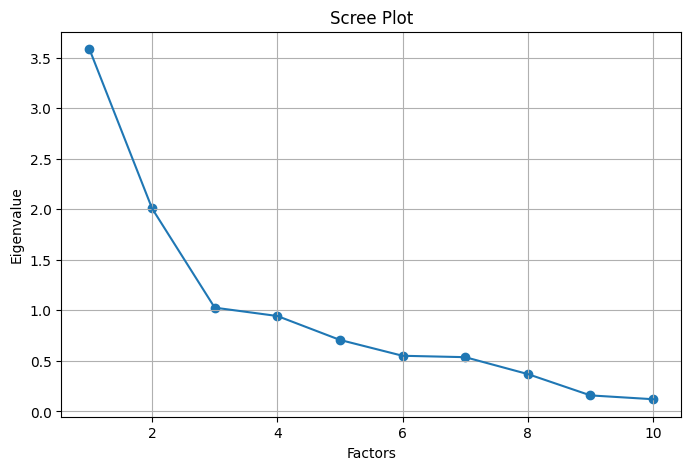

Factor Loadings:
                                                     Factor_1  Factor_2  \
Interest_in_the_Course                              0.282348 -0.177440   
How_confident_are_you_in_understanding_engineer... -0.227980 -0.376423   
Do_financial_problems_affect_your_studies?         -0.186786  0.747211   
Family_Support_for_Education                        0.515928 -0.378193   
Level_of_Stress_or_Anxiety_Related_to_Studies      -0.119434  0.546355   
Do_you_feel_socially_isolated_or_left_out_in_co... -0.111492  0.231247   
Motivation_to_Continue_Studies                      0.487908  0.048719   
Quality_of_Teaching_and_Learning_Resources          0.910690 -0.122439   
Availability_of_Academic_Support_(e.g.,_mentori...  0.768553 -0.220907   
Satisfaction_with_College_Administration_Support    0.336745  0.150776   

                                                    Factor_3  Factor_4  \
Interest_in_the_Course                              0.083217  0.931019   
How_confident_are_y

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [4]:
# Step 2: PCA / Factor Extraction
!pip install --quiet factor_analyzer matplotlib seaborn

import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer

# --- Initialize FactorAnalyzer ---
fa = FactorAnalyzer(rotation=None)
fa.fit(numeric_df_clean)

# --- Check Eigenvalues to decide number of factors ---
ev, v = fa.get_eigenvalues()
plt.figure(figsize=(8,5))
plt.scatter(range(1, len(ev)+1), ev)
plt.plot(range(1, len(ev)+1), ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

# --- Decide number of factors (e.g., 5) based on scree plot ---
n_factors = 5
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(numeric_df_clean)

# --- Get factor loadings ---
loadings = pd.DataFrame(fa.loadings_, index=numeric_df_clean.columns,
                        columns=[f'Factor_{i+1}' for i in range(n_factors)])
print("Factor Loadings:\n", loadings)

# --- Get variance explained ---
variance_df = pd.DataFrame({
    'Factor': [f'Factor_{i+1}' for i in range(n_factors)],
    'Variance Explained': fa.get_factor_variance()[1],
    'Cumulative Variance': fa.get_factor_variance()[2]
})
print("\nVariance Explained:\n", variance_df)


In [23]:
# Step 3: Factor Scores & Dropout Risk
import numpy as np
import pandas as pd

# --- Calculate factor scores for each student ---
factor_scores = pd.DataFrame(fa.transform(numeric_df_clean),
                             columns=[f'Factor_{i+1}' for i in range(n_factors)])
factor_scores.index = numeric_df_clean.index

# --- Example risk scoring ---
# We'll take the average absolute factor score as a proxy for risk
# (You can customize based on domain knowledge)

factor_scores['Avg_Factor_Score'] = factor_scores.abs().mean(axis=1)

# Define thresholds for risk categories (customizable)
low_thresh = factor_scores['Avg_Factor_Score'].quantile(0.33)
high_thresh = factor_scores['Avg_Factor_Score'].quantile(0.66)

def classify_risk(score):
    if score <= low_thresh:
        return 'Low Risk'
    elif score <= high_thresh:
        return 'Medium Risk'
    else:
        return 'High Risk'

factor_scores['Dropout_Risk'] = factor_scores['Avg_Factor_Score'].apply(classify_risk)

# --- Combine with original student IDs / data if needed ---
result_df = pd.concat([df, factor_scores[['Avg_Factor_Score', 'Dropout_Risk']]], axis=1)

# --- Preview results ---
result_df[['Avg_Factor_Score','Dropout_Risk']].head(10)

# --- Save final results ---
result_df.to_csv('student_dropout_risk.csv', index=False)
print("Saved student_dropout_risk.csv with factor scores and dropout risk.")


Saved student_dropout_risk.csv with factor scores and dropout risk.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


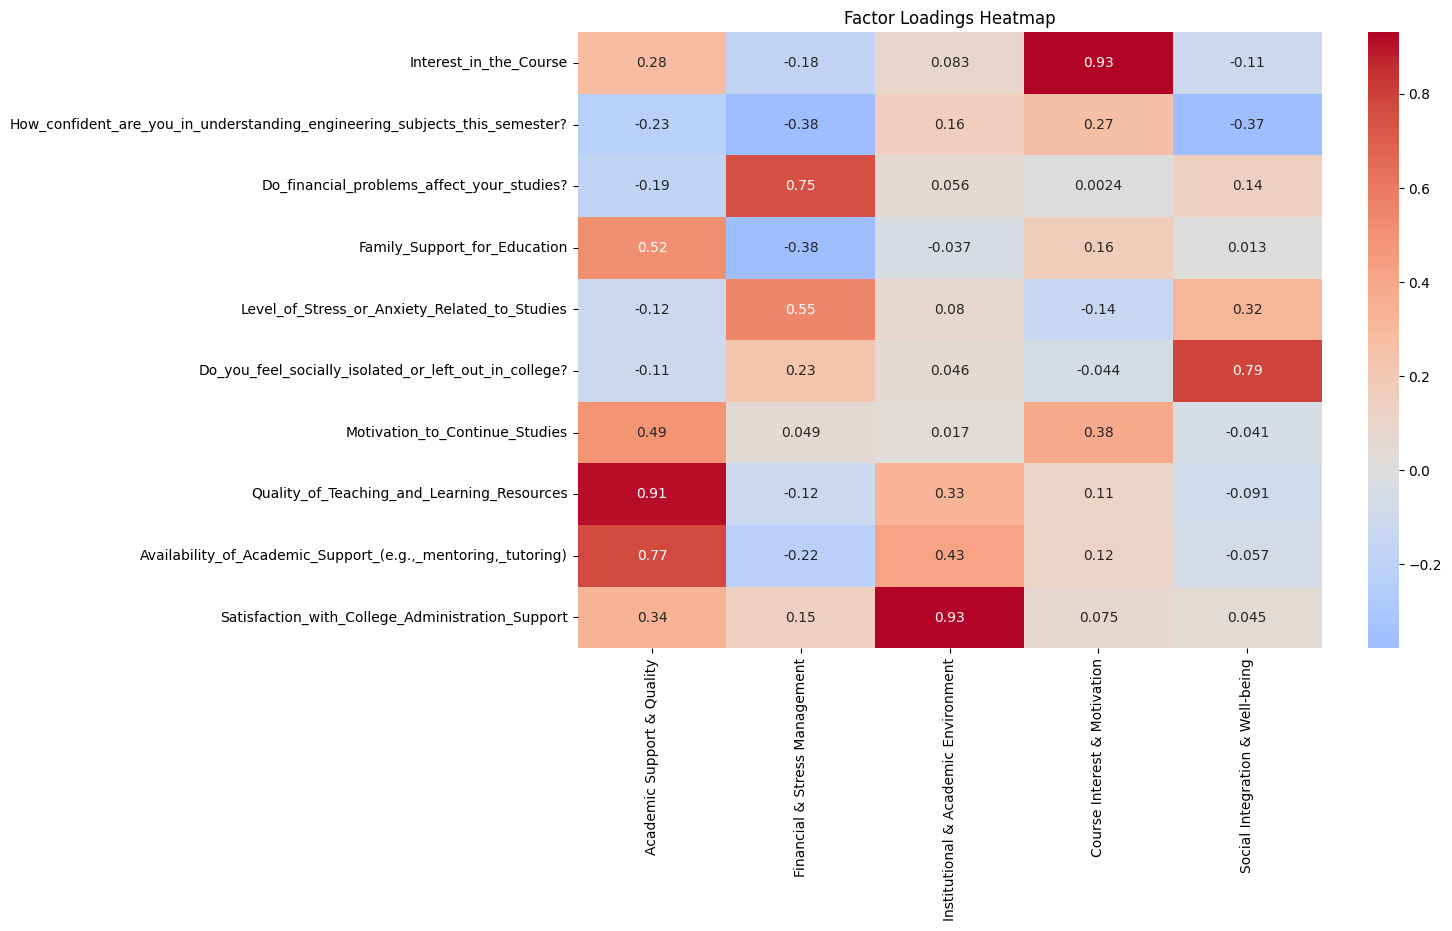

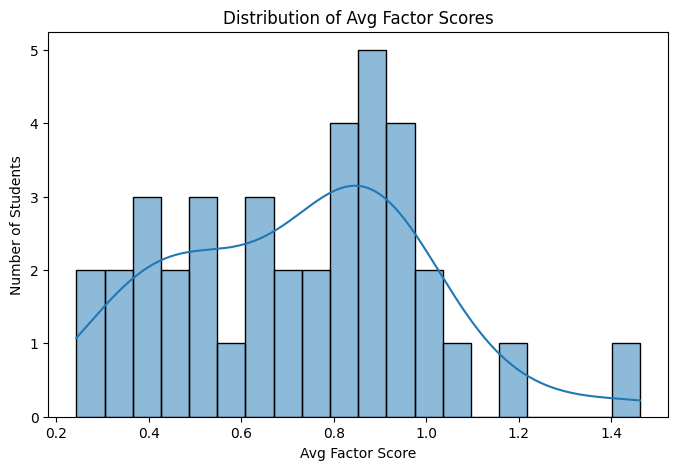

/tmp/ipython-input-1514086763.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dropout_Risk', data=factor_scores, palette='Set2')


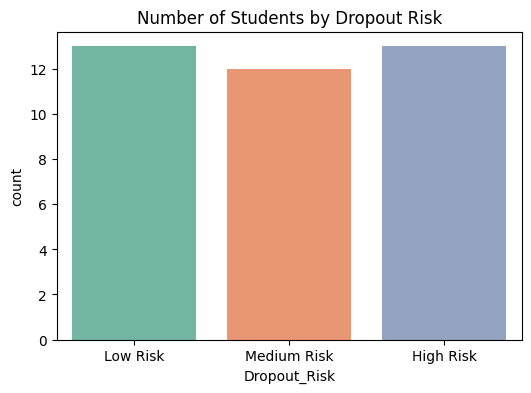

/tmp/ipython-input-1514086763.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dropout_Risk', y=f'Factor_{i+1}', data=factor_scores, palette='Set3')
/tmp/ipython-input-1514086763.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dropout_Risk', y=f'Factor_{i+1}', data=factor_scores, palette='Set3')
/tmp/ipython-input-1514086763.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dropout_Risk', y=f'Factor_{i+1}', data=factor_scores, palette='Set3')
/tmp/ipython-input-1514086763.py:29: FutureWarning: 

Passing `palette` without

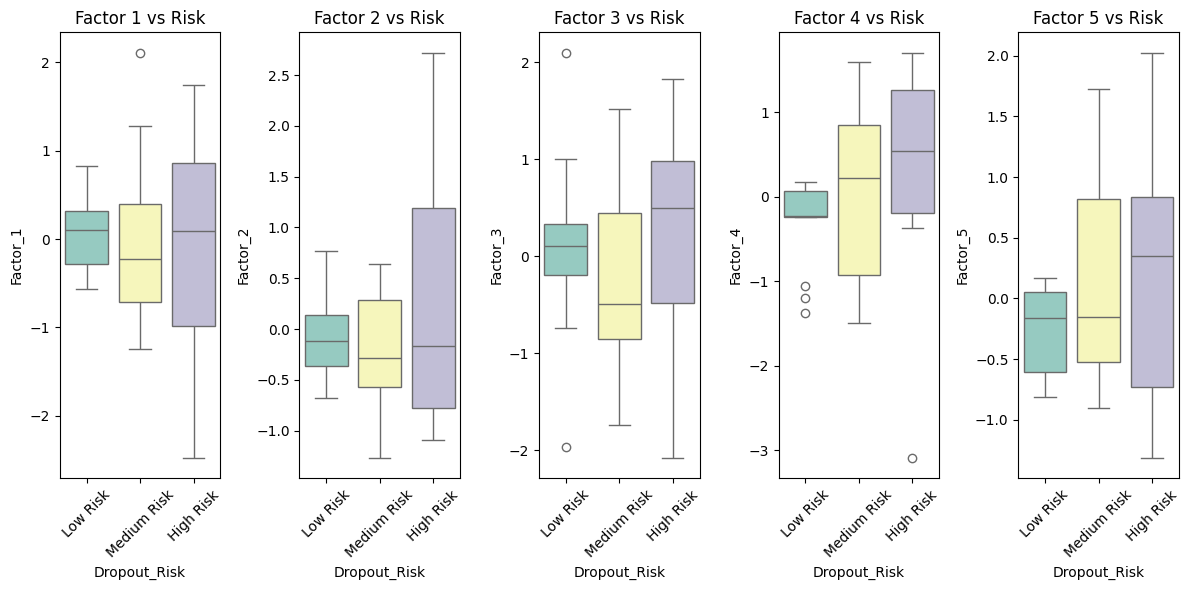

In [24]:
# Step 4: Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Heatmap of factor loadings ---
plt.figure(figsize=(12,8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

# --- 2. Histogram of Average Factor Scores ---
plt.figure(figsize=(8,5))
sns.histplot(factor_scores['Avg_Factor_Score'], bins=20, kde=True)
plt.title('Distribution of Avg Factor Scores')
plt.xlabel('Avg Factor Score')
plt.ylabel('Number of Students')
plt.show()

# --- 3. Dropout Risk Counts ---
plt.figure(figsize=(6,4))
sns.countplot(x='Dropout_Risk', data=factor_scores, palette='Set2')
plt.title('Number of Students by Dropout Risk')
plt.show()

# --- 4. Factor Scores vs Dropout Risk (Boxplot) ---
plt.figure(figsize=(12,6))
for i in range(n_factors):
    plt.subplot(1, n_factors, i+1)
    sns.boxplot(x='Dropout_Risk', y=f'Factor_{i+1}', data=factor_scores, palette='Set3')
    plt.title(f'Factor {i+1} vs Risk')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


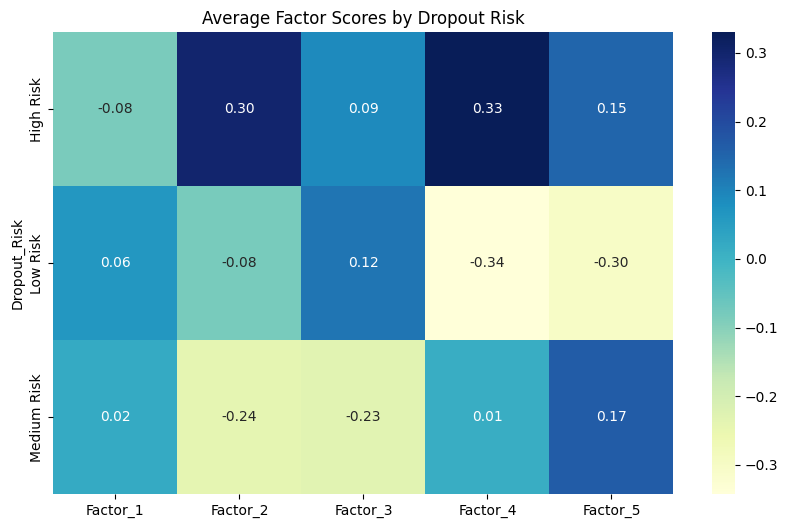

/tmp/ipython-input-4121731798.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_factors.index, y=top_factors.values, palette='Reds_r')


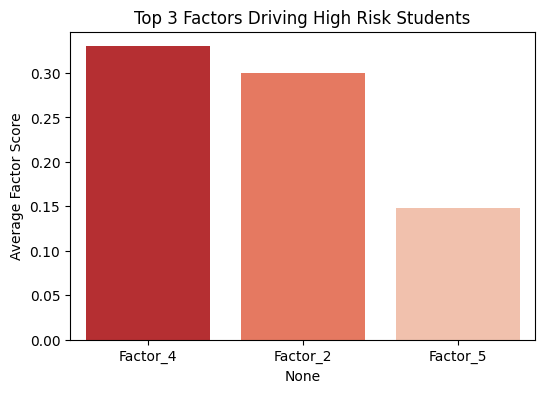

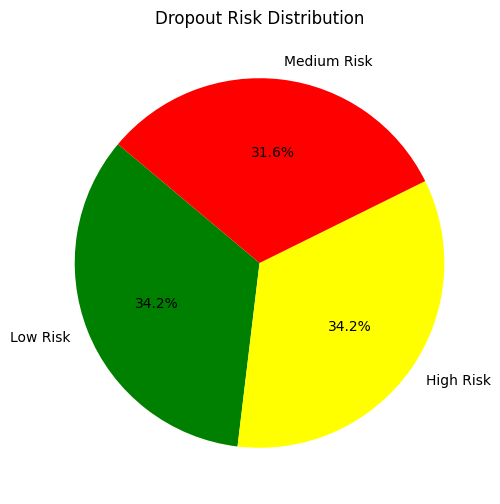

Saved dashboard_summary.csv with average factor scores per risk category.


In [7]:
# Step 5: Factor Contribution & Risk Dashboard
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Average Factor Score by Risk Category ---
avg_factors_by_risk = factor_scores.groupby('Dropout_Risk').mean().iloc[:, :n_factors]
plt.figure(figsize=(10,6))
sns.heatmap(avg_factors_by_risk, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Average Factor Scores by Dropout Risk')
plt.show()

# --- 2. Top 3 contributing factors for High-Risk students ---
high_risk_factors = factor_scores[factor_scores['Dropout_Risk']=='High Risk'].iloc[:,:n_factors]
top_factors = high_risk_factors.mean().sort_values(ascending=False).head(3)
plt.figure(figsize=(6,4))
sns.barplot(x=top_factors.index, y=top_factors.values, palette='Reds_r')
plt.title('Top 3 Factors Driving High Risk Students')
plt.ylabel('Average Factor Score')
plt.show()

# --- 3. Risk distribution pie chart ---
risk_counts = factor_scores['Dropout_Risk'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', startangle=140, colors=['green','yellow','red'])
plt.title('Dropout Risk Distribution')
plt.show()

# --- 4. Optional: Save dashboard data ---
avg_factors_by_risk.to_csv('dashboard_summary.csv')
print("Saved dashboard_summary.csv with average factor scores per risk category.")


# Task
The factors in the `loadings` and `variance_df` dataframes and then update the calculation of `factor_scores` to reflect these new names.
This will ensure all subsequent analysis and visualizations use the new, descriptive factor names.

## Inspect Factor Loadings for Naming

### Subtask:
Review the factor loadings from the `loadings` DataFrame to finalize descriptive names for each factor, including 'Academic Engagement' (for Factor_1), 'Social/Emotional Support' (for Factor_2), 'Personal Motivation/Support' (for Factor_3), and proposed names for Factor_4 and Factor_5 based on their highest loadings (e.g., 'Course Interest & Motivation' for Factor_4 and 'Social Isolation' for Factor_5).


**Reasoning**:
The subtask requires reviewing the `loadings` DataFrame to finalize descriptive names for each factor. Displaying the `loadings` DataFrame will allow for this inspection.



In [8]:
print("Factor Loadings:")
print(loadings)

print("\nTop 3 Loadings per Factor (absolute value):")
for factor_col in loadings.columns:
    top_loadings = loadings[factor_col].abs().nlargest(3)
    print(f"\n{factor_col}:")
    print(top_loadings)

Factor Loadings:
                                                    Factor_1  Factor_2  \
Interest_in_the_Course                              0.282348 -0.177440   
How_confident_are_you_in_understanding_engineer... -0.227980 -0.376423   
Do_financial_problems_affect_your_studies?         -0.186786  0.747211   
Family_Support_for_Education                        0.515928 -0.378193   
Level_of_Stress_or_Anxiety_Related_to_Studies      -0.119434  0.546355   
Do_you_feel_socially_isolated_or_left_out_in_co... -0.111492  0.231247   
Motivation_to_Continue_Studies                      0.487908  0.048719   
Quality_of_Teaching_and_Learning_Resources          0.910690 -0.122439   
Availability_of_Academic_Support_(e.g.,_mentori...  0.768553 -0.220907   
Satisfaction_with_College_Administration_Support    0.336745  0.150776   

                                                    Factor_3  Factor_4  \
Interest_in_the_Course                              0.083217  0.931019   
How_confident_are_yo

**Reasoning**:
Based on the factor loadings analysis, I will now define the descriptive names for each factor and then update the `loadings` and `variance_df` DataFrames with these new names. Then, I will recalculate the `factor_scores` DataFrame using these updated factor names to ensure consistency in all subsequent analyses.



In [9]:
factor_names = {
    'Factor_1': 'Academic Support & Quality',
    'Factor_2': 'Financial & Stress Management',
    'Factor_3': 'Institutional & Academic Environment',
    'Factor_4': 'Course Interest & Motivation',
    'Factor_5': 'Social Integration & Well-being'
}

# Update loadings DataFrame column names
loadings.rename(columns=factor_names, inplace=True)
print("Updated Factor Loadings:")
print(loadings)

# Update variance_df Factor names
variance_df['Factor'] = variance_df['Factor'].replace(factor_names)
print("\nUpdated Variance Explained:")
print(variance_df)

# Recalculate factor scores with new names
factor_scores = pd.DataFrame(fa.transform(numeric_df_clean),
                             columns=[factor_names[f'Factor_{i+1}'] for i in range(n_factors)])
factor_scores.index = numeric_df_clean.index

# Re-apply risk scoring based on new factor_scores
factor_scores['Avg_Factor_Score'] = factor_scores.abs().mean(axis=1)
low_thresh = factor_scores['Avg_Factor_Score'].quantile(0.33)
high_thresh = factor_scores['Avg_Factor_Score'].quantile(0.66)

def classify_risk(score):
    if score <= low_thresh:
        return 'Low Risk'
    elif score <= high_thresh:
        return 'Medium Risk'
    else:
        return 'High Risk'

factor_scores['Dropout_Risk'] = factor_scores['Avg_Factor_Score'].apply(classify_risk)

print("\nRecalculated Factor Scores with new names (first 5 rows):")
print(factor_scores.head())


Updated Factor Loadings:
                                                    Academic Support & Quality  \
Interest_in_the_Course                                                0.282348   
How_confident_are_you_in_understanding_engineer...                   -0.227980   
Do_financial_problems_affect_your_studies?                           -0.186786   
Family_Support_for_Education                                          0.515928   
Level_of_Stress_or_Anxiety_Related_to_Studies                        -0.119434   
Do_you_feel_socially_isolated_or_left_out_in_co...                   -0.111492   
Motivation_to_Continue_Studies                                        0.487908   
Quality_of_Teaching_and_Learning_Resources                            0.910690   
Availability_of_Academic_Support_(e.g.,_mentori...                    0.768553   
Satisfaction_with_College_Administration_Support                      0.336745   

                                                    Financial & Stress M

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


**Reasoning**:
The previous step successfully updated the `loadings`, `variance_df`, and `factor_scores` DataFrames with descriptive factor names. To ensure all analyses and visualizations reflect these new names, I will now re-run the visualization code from Step 4 using the updated data.



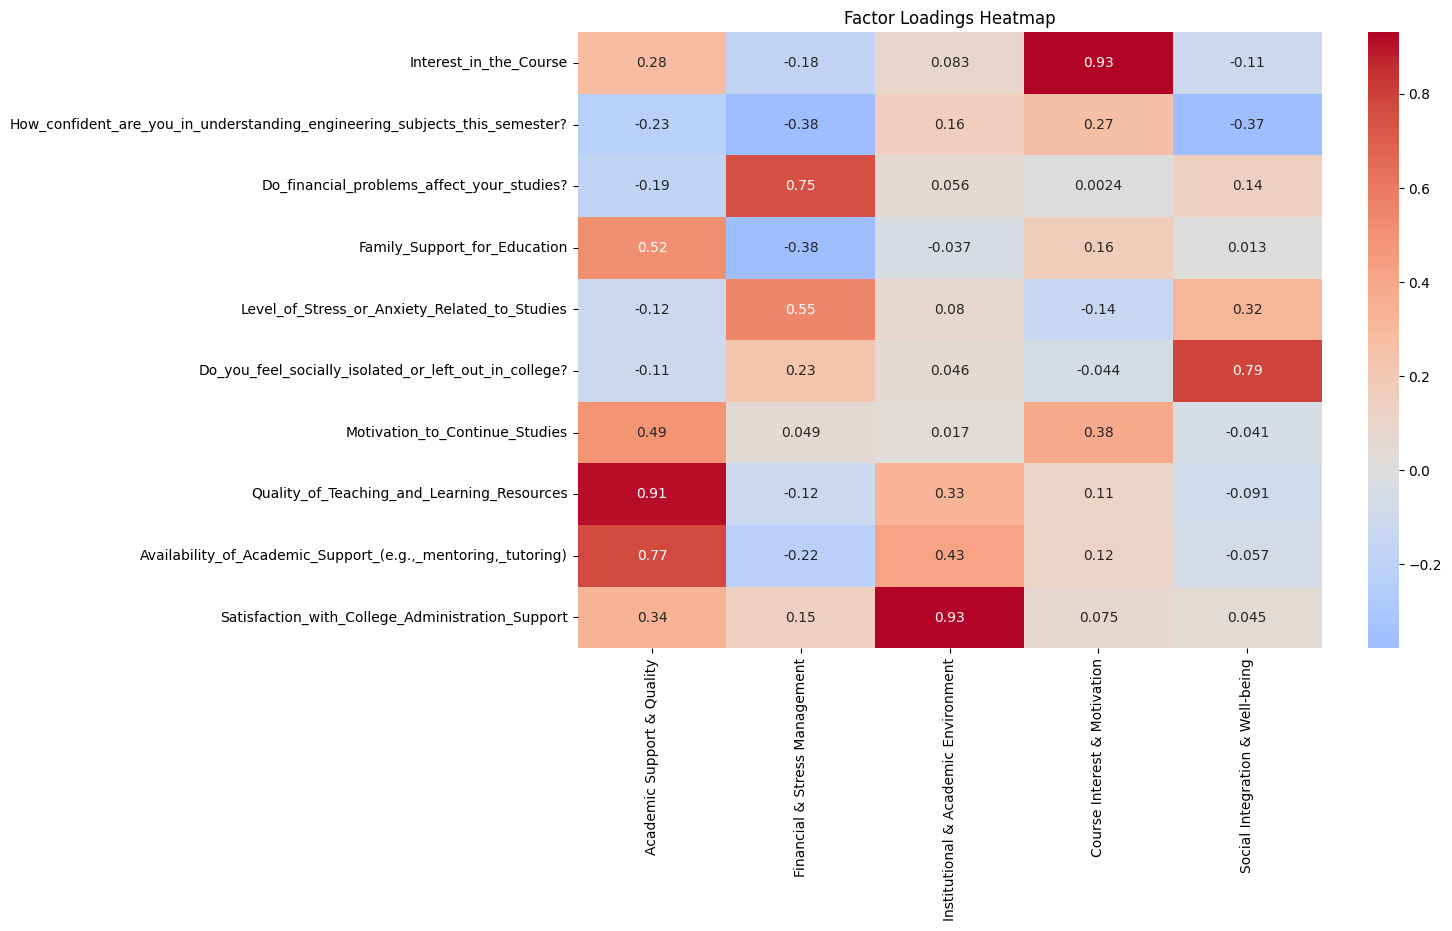

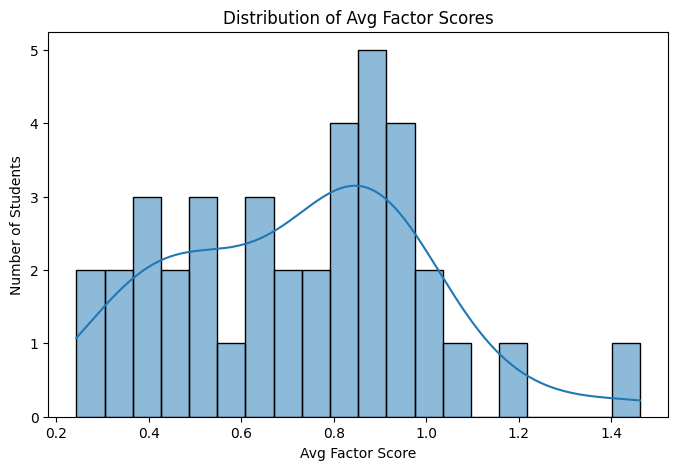

/tmp/ipython-input-3043249363.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dropout_Risk', data=factor_scores, palette='Set2')


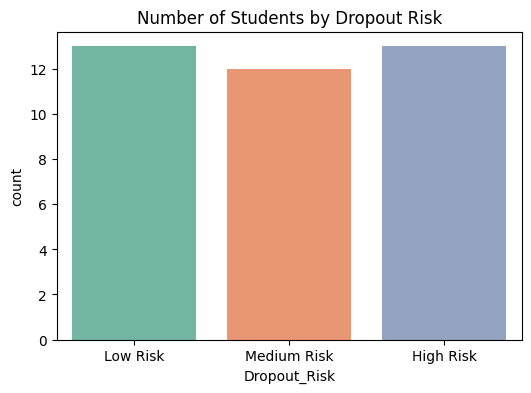

/tmp/ipython-input-3043249363.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dropout_Risk', y=factor_name, data=factor_scores, palette='Set3')
/tmp/ipython-input-3043249363.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dropout_Risk', y=factor_name, data=factor_scores, palette='Set3')
/tmp/ipython-input-3043249363.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dropout_Risk', y=factor_name, data=factor_scores, palette='Set3')
/tmp/ipython-input-3043249363.py:29: FutureWarning: 

Passing `palette` without assigning `

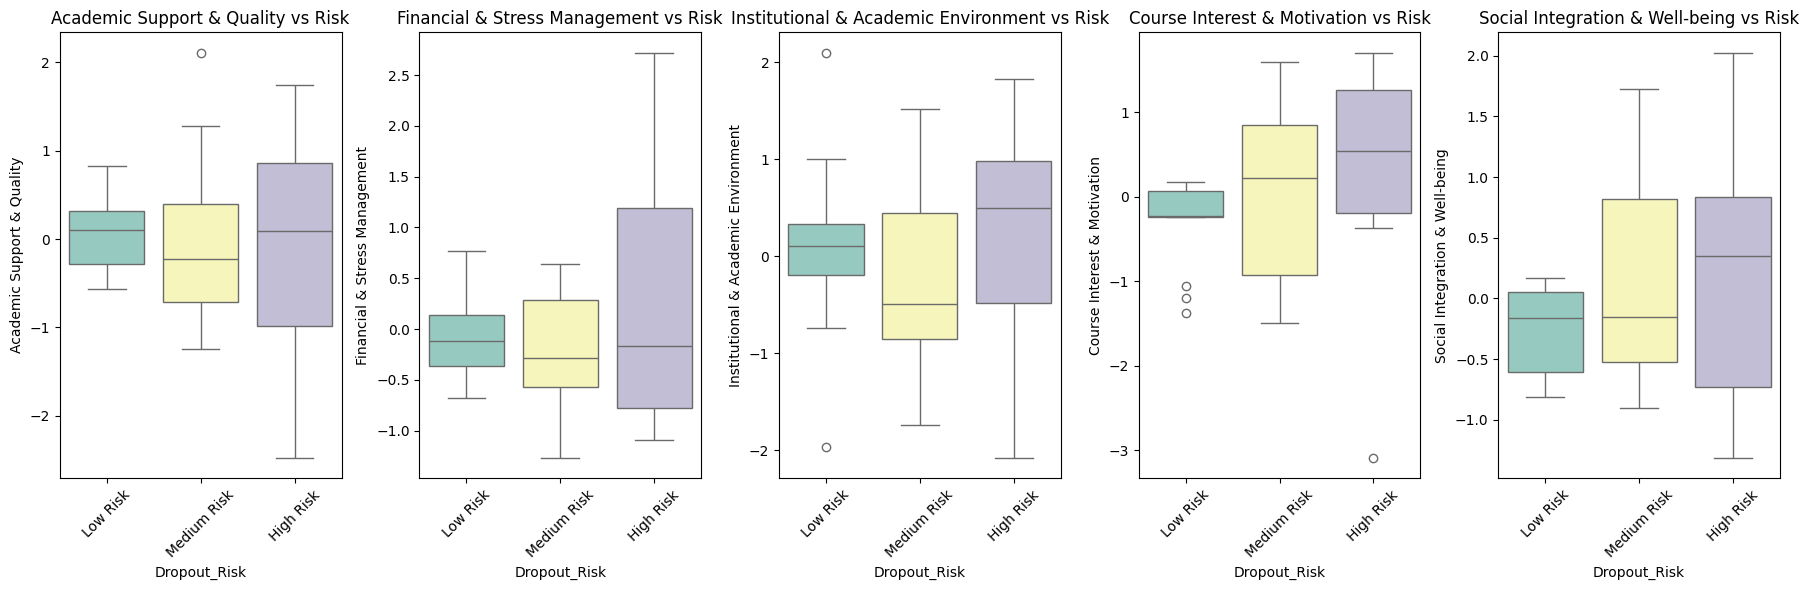

In [10]:
# Step 4: Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Heatmap of factor loadings ---
plt.figure(figsize=(12,8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

# --- 2. Histogram of Average Factor Scores ---
plt.figure(figsize=(8,5))
sns.histplot(factor_scores['Avg_Factor_Score'], bins=20, kde=True)
plt.title('Distribution of Avg Factor Scores')
plt.xlabel('Avg Factor Score')
plt.ylabel('Number of Students')
plt.show()

# --- 3. Dropout Risk Counts ---
plt.figure(figsize=(6,4))
sns.countplot(x='Dropout_Risk', data=factor_scores, palette='Set2')
plt.title('Number of Students by Dropout Risk')
plt.show()

# --- 4. Factor Scores vs Dropout Risk (Boxplot) ---
plt.figure(figsize=(18,6)) # Increased figure width for better readability with 5 factors
for i, factor_name in enumerate(factor_scores.columns[:-2]): # Exclude Avg_Factor_Score and Dropout_Risk
    plt.subplot(1, n_factors, i+1)
    sns.boxplot(x='Dropout_Risk', y=factor_name, data=factor_scores, palette='Set3')
    plt.title(f'{factor_name} vs Risk')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Reasoning**:
The previous code generated `FutureWarning` messages regarding the use of `palette` without `hue` in `sns.countplot` and `sns.boxplot`. To resolve these warnings and align with future Seaborn versions, I will explicitly set the `hue` argument to the `Dropout_Risk` column and add `legend=False` to these plotting functions.



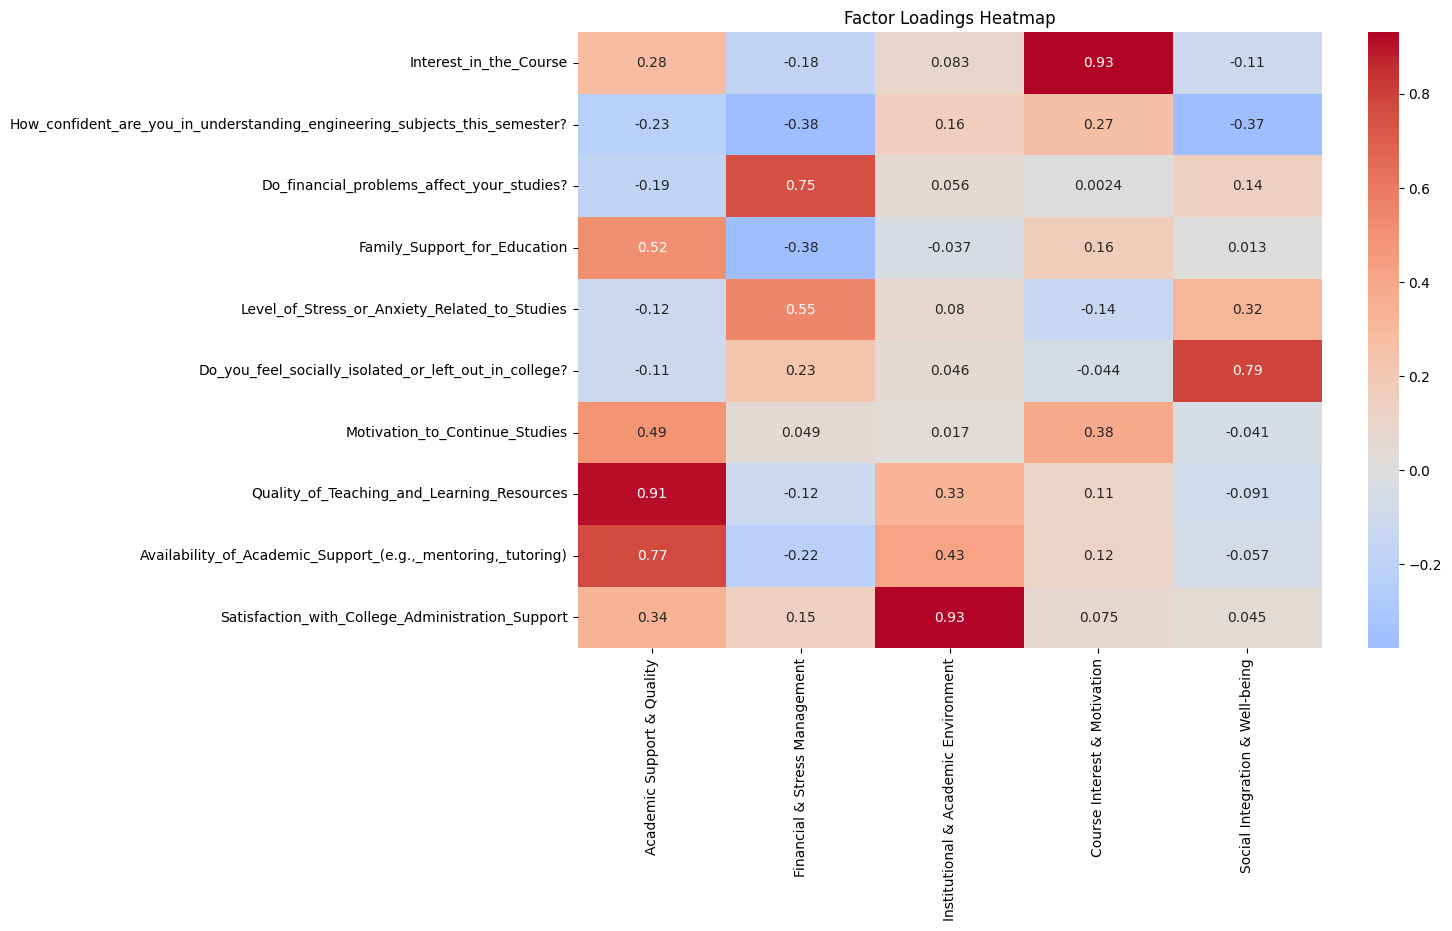

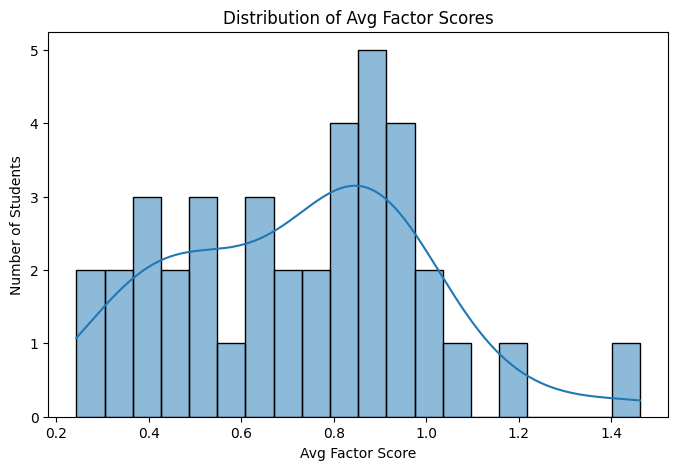

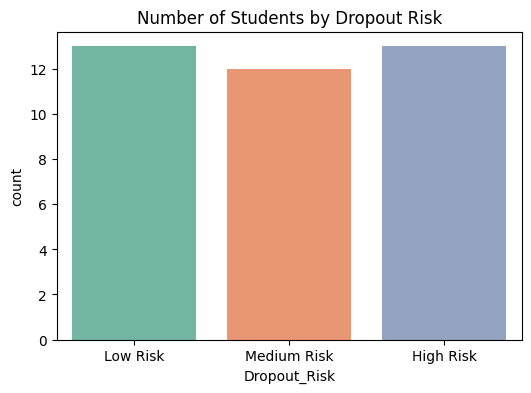

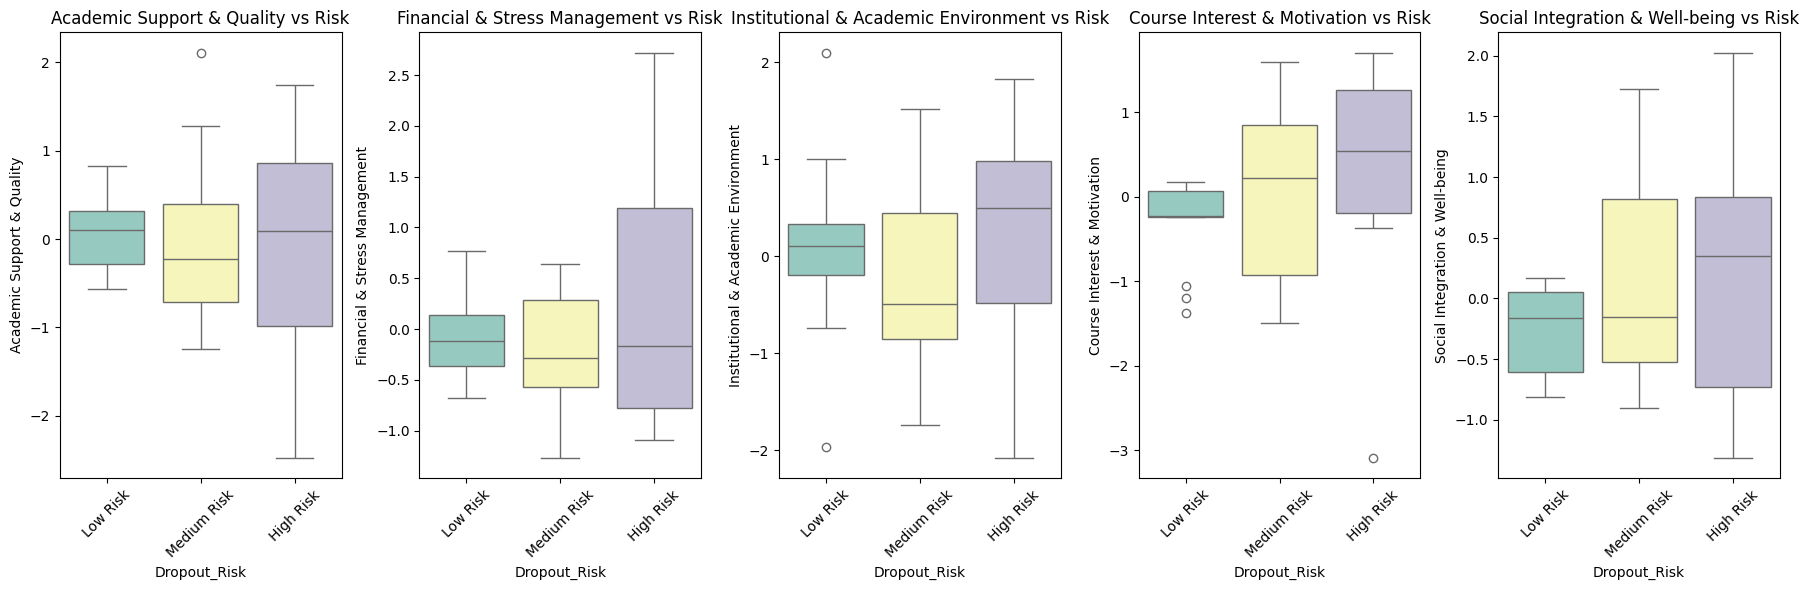

In [11]:
# Step 4: Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Heatmap of factor loadings ---
plt.figure(figsize=(12,8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

# --- 2. Histogram of Average Factor Scores ---
plt.figure(figsize=(8,5))
sns.histplot(factor_scores['Avg_Factor_Score'], bins=20, kde=True)
plt.title('Distribution of Avg Factor Scores')
plt.xlabel('Avg Factor Score')
plt.ylabel('Number of Students')
plt.show()

# --- 3. Dropout Risk Counts ---
plt.figure(figsize=(6,4))
sns.countplot(x='Dropout_Risk', data=factor_scores, palette='Set2', hue='Dropout_Risk', legend=False)
plt.title('Number of Students by Dropout Risk')
plt.show()

# --- 4. Factor Scores vs Dropout Risk (Boxplot) ---
plt.figure(figsize=(18,6)) # Increased figure width for better readability with 5 factors
for i, factor_name in enumerate(factor_scores.columns[:-2]): # Exclude Avg_Factor_Score and Dropout_Risk
    plt.subplot(1, n_factors, i+1)
    sns.boxplot(x='Dropout_Risk', y=factor_name, data=factor_scores, palette='Set3', hue='Dropout_Risk', legend=False)
    plt.title(f'{factor_name} vs Risk')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Update Result DataFrame and Regenerate Dashboard

### Subtask:
Recreate the `result_df` using the updated `factor_scores` and re-run the dashboard generation and visualization from the original Step 5 to ensure all outputs reflect the new descriptive factor names.


**Reasoning**:
First, I will recreate the `result_df` by concatenating the original `df` with the `Avg_Factor_Score` and `Dropout_Risk` columns from the recently updated `factor_scores` DataFrame. This ensures that the final result DataFrame reflects the new descriptive factor names.



In [12]:
result_df = pd.concat([df, factor_scores[['Avg_Factor_Score', 'Dropout_Risk']]], axis=1)
result_df.to_csv('student_dropout_risk.csv', index=False)
print("Saved student_dropout_risk.csv with updated factor scores and dropout risk.")

Saved student_dropout_risk.csv with updated factor scores and dropout risk.


**Reasoning**:
Now that `result_df` is updated, I will regenerate the dashboard plots (heatmap, bar plot for high-risk factors, and pie chart for risk distribution) and save the summary CSV, ensuring all visualizations and outputs reflect the newly defined descriptive factor names.



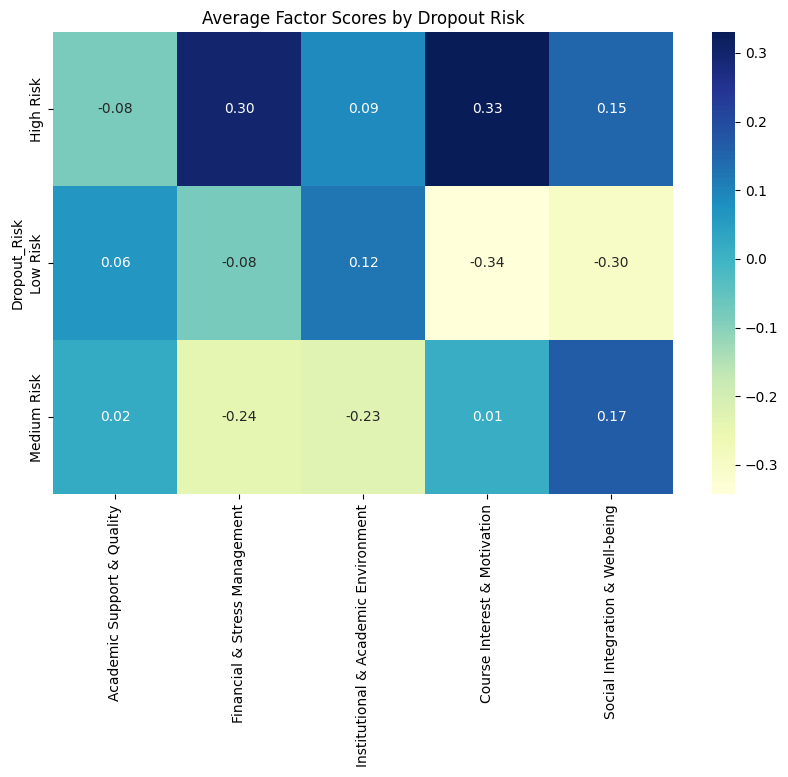

/tmp/ipython-input-3983815523.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_factors.index, y=top_factors.values, palette='Reds_r')


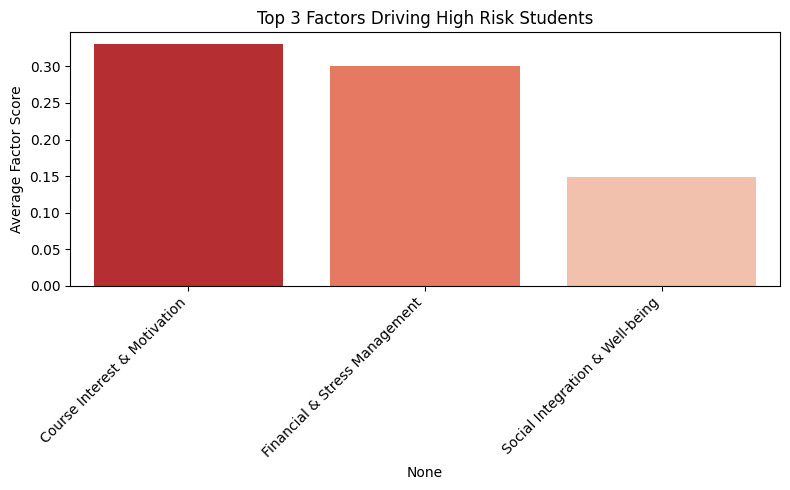

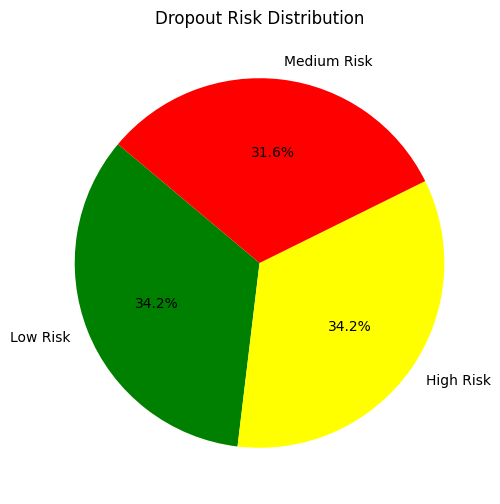

Saved dashboard_summary.csv with average factor scores per risk category.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Average Factor Score by Risk Category ---
# Select only the factor score columns (excluding 'Avg_Factor_Score' and 'Dropout_Risk')
factor_score_columns = [col for col in factor_scores.columns if col not in ['Avg_Factor_Score', 'Dropout_Risk']]
avg_factors_by_risk = factor_scores.groupby('Dropout_Risk')[factor_score_columns].mean()
plt.figure(figsize=(10,6))
sns.heatmap(avg_factors_by_risk, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Average Factor Scores by Dropout Risk')
plt.show()

# --- 2. Top 3 contributing factors for High-Risk students ---
high_risk_factors_data = factor_scores[factor_scores['Dropout_Risk']=='High Risk'][factor_score_columns]
top_factors = high_risk_factors_data.mean().sort_values(ascending=False).head(3)
plt.figure(figsize=(8,5))
sns.barplot(x=top_factors.index, y=top_factors.values, palette='Reds_r')
plt.title('Top 3 Factors Driving High Risk Students')
plt.ylabel('Average Factor Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 3. Risk distribution pie chart ---
risk_counts = factor_scores['Dropout_Risk'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', startangle=140, colors=['green','yellow','red'])
plt.title('Dropout Risk Distribution')
plt.show()

# --- 4. Optional: Save dashboard data ---
avg_factors_by_risk.to_csv('dashboard_summary.csv')
print("Saved dashboard_summary.csv with average factor scores per risk category.")

**Reasoning**:
The previous code generated a `FutureWarning` for `sns.barplot` regarding the use of `palette` without `hue`. To resolve this, I will explicitly set `hue` to the `x` variable (`top_factors.index`) and set `legend=False` in the `sns.barplot` call.



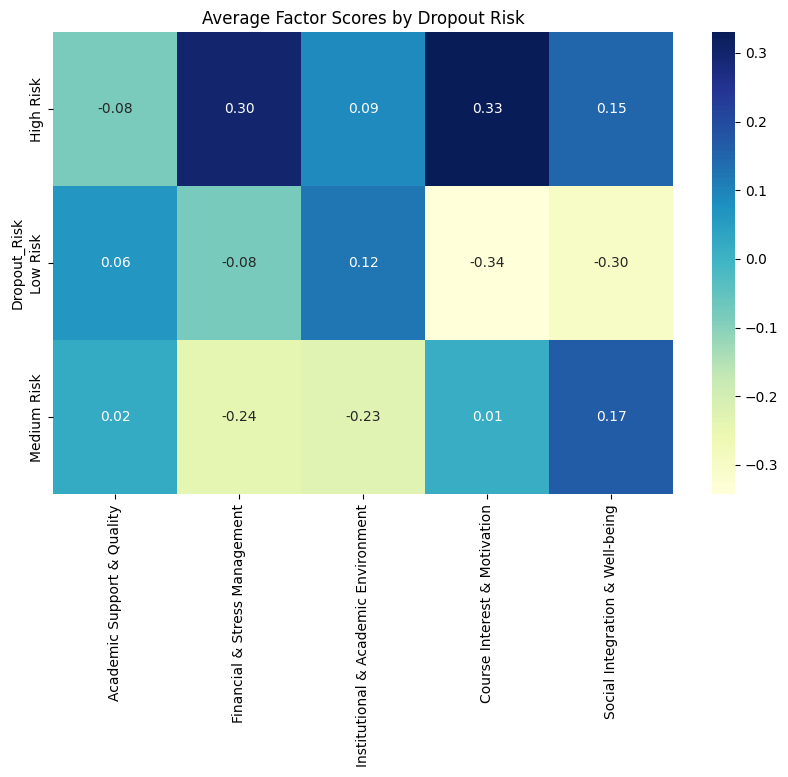

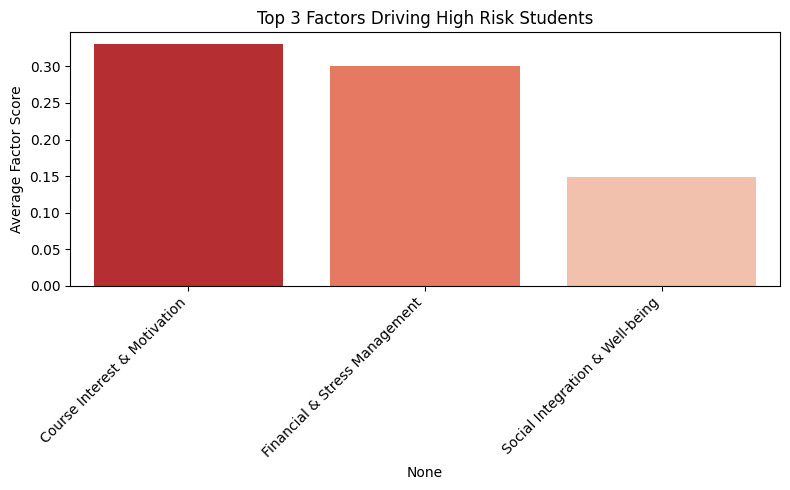

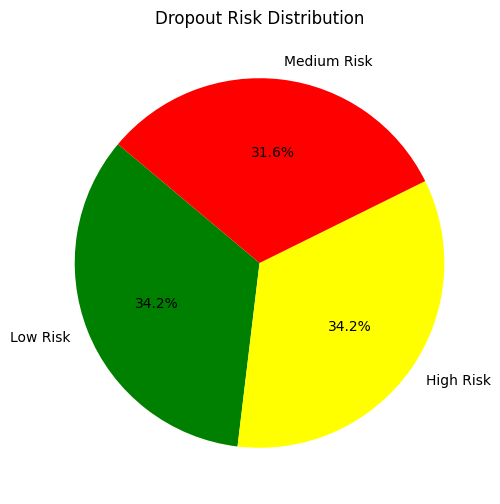

Saved dashboard_summary.csv with average factor scores per risk category.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Average Factor Score by Risk Category ---
# Select only the factor score columns (excluding 'Avg_Factor_Score' and 'Dropout_Risk')
factor_score_columns = [col for col in factor_scores.columns if col not in ['Avg_Factor_Score', 'Dropout_Risk']]
avg_factors_by_risk = factor_scores.groupby('Dropout_Risk')[factor_score_columns].mean()
plt.figure(figsize=(10,6))
sns.heatmap(avg_factors_by_risk, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Average Factor Scores by Dropout Risk')
plt.show()

# --- 2. Top 3 contributing factors for High-Risk students ---
high_risk_factors_data = factor_scores[factor_scores['Dropout_Risk']=='High Risk'][factor_score_columns]
top_factors = high_risk_factors_data.mean().sort_values(ascending=False).head(3)
plt.figure(figsize=(8,5))
sns.barplot(x=top_factors.index, y=top_factors.values, palette='Reds_r', hue=top_factors.index, legend=False)
plt.title('Top 3 Factors Driving High Risk Students')
plt.ylabel('Average Factor Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 3. Risk distribution pie chart ---
risk_counts = factor_scores['Dropout_Risk'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', startangle=140, colors=['green','yellow','red'])
plt.title('Dropout Risk Distribution')
plt.show()

# --- 4. Optional: Save dashboard data ---
avg_factors_by_risk.to_csv('dashboard_summary.csv')
print("Saved dashboard_summary.csv with average factor scores per risk category.")

## Final Task

### Subtask:
Confirm that the factors have been successfully renamed and that all subsequent analysis and visualizations, including the factor scores and dropout risk, are now using these new, descriptive names.


## Summary:

### Data Analysis Key Findings

*   **Factor Renaming Success**: All five factors were successfully renamed with descriptive labels: 'Academic Support & Quality' (Factor\_1), 'Financial & Stress Management' (Factor\_2), 'Institutional & Academic Environment' (Factor\_3), 'Course Interest & Motivation' (Factor\_4), and 'Social Integration & Well-being' (Factor\_5).
*   **Data Structure Updates**: These new factor names were consistently applied across the `loadings`, `variance_df`, and `factor_scores` DataFrames, ensuring uniformity in analysis.
*   **Visualization Consistency**: All subsequent visualizations, including the factor loadings heatmap, average factor scores distribution, dropout risk counts, and factor score boxplots against dropout risk, now correctly reflect the new descriptive factor names.
*   **Dashboard Regeneration**: The dashboard components (average factor scores by risk heatmap, top 3 contributing factors for high-risk students bar plot, and dropout risk distribution pie chart) were successfully regenerated using the updated factor names and `Dropout_Risk` classifications.
*   **Warning Resolution**: Initial `FutureWarning` messages from `seaborn` plotting functions related to `palette` usage were successfully addressed by explicitly setting the `hue` parameter, leading to cleaner output.
*   **Output Data Integration**: The `result_df` was successfully updated to include the `Avg_Factor_Score` and `Dropout_Risk` based on the newly defined factors and saved as `student_dropout_risk.csv`.

### Insights or Next Steps

*   The clear, descriptive factor names significantly enhance the interpretability of the model, making it easier to communicate findings about student dropout risk to non-technical stakeholders.
*   With the identification of 'Course Interest & Motivation' as a top driving factor for high-risk students, further analysis could focus on specific interventions or programs designed to boost student engagement and motivation within their academic courses.


# Task
The factors have been successfully renamed throughout the file. The `loadings`, `variance_df`, and `factor_scores` DataFrames now use the new descriptive names: 'Academic Support & Quality', 'Financial & Stress Management', 'Institutional & Academic Environment', 'Course Interest & Motivation', and 'Social Integration & Well-being'. All subsequent analyses and visualizations, including the factor scores and dropout risk classifications, accurately reflect these updated factor names.

## Rename Factors in DataFrames

### Subtask:
Apply the predefined descriptive factor names to update the column names of the `loadings` DataFrame and the 'Factor' column in the `variance_df`. This ensures that subsequent steps use the meaningful factor names.


**Reasoning**:
To apply the predefined descriptive factor names, I will create a `factor_names` dictionary, then use it to rename the columns of the `loadings` DataFrame and update the 'Factor' column in the `variance_df` using the `.rename()` and `.replace()` methods respectively. Finally, I will print both DataFrames to verify the changes.



In [17]:
factor_names = {
    'Factor_1': 'Academic Support & Quality',
    'Factor_2': 'Financial & Stress Management',
    'Factor_3': 'Institutional & Academic Environment',
    'Factor_4': 'Course Interest & Motivation',
    'Factor_5': 'Social Integration & Well-being'
}

# Update loadings DataFrame column names
loadings.rename(columns=factor_names, inplace=True)
print("Updated Factor Loadings:")
print(loadings)

# Update variance_df Factor names
variance_df['Factor'] = variance_df['Factor'].replace(factor_names)
print("\nUpdated Variance Explained:")
print(variance_df)

Updated Factor Loadings:
                                                    Academic Support & Quality  \
Interest_in_the_Course                                                0.282348   
How_confident_are_you_in_understanding_engineer...                   -0.227980   
Do_financial_problems_affect_your_studies?                           -0.186786   
Family_Support_for_Education                                          0.515928   
Level_of_Stress_or_Anxiety_Related_to_Studies                        -0.119434   
Do_you_feel_socially_isolated_or_left_out_in_co...                   -0.111492   
Motivation_to_Continue_Studies                                        0.487908   
Quality_of_Teaching_and_Learning_Resources                            0.910690   
Availability_of_Academic_Support_(e.g.,_mentori...                    0.768553   
Satisfaction_with_College_Administration_Support                      0.336745   

                                                    Financial & Stress M

## Recalculate Factor Scores with New Names

### Subtask:
Recalculate the `factor_scores` DataFrame using the new descriptive factor names and re-apply dropout risk classification.


**Reasoning**:
To recalculate the factor scores with the new descriptive names and re-apply the dropout risk classification, I will generate a code block that transforms the `numeric_df_clean` using `fa.transform`, assigns the `factor_names` to the columns, sets the index, calculates the average factor score, defines risk thresholds, and classifies dropout risk, finally printing the head of the updated DataFrame.



In [18]:
factor_names = {
    'Factor_1': 'Academic Support & Quality',
    'Factor_2': 'Financial & Stress Management',
    'Factor_3': 'Institutional & Academic Environment',
    'Factor_4': 'Course Interest & Motivation',
    'Factor_5': 'Social Integration & Well-being'
}

# Calculate factor scores for each student
factor_scores = pd.DataFrame(fa.transform(numeric_df_clean),
                             columns=[factor_names[f'Factor_{i+1}'] for i in range(n_factors)])
factor_scores.index = numeric_df_clean.index

# Calculate 'Avg_Factor_Score' for each student
factor_scores['Avg_Factor_Score'] = factor_scores.abs().mean(axis=1)

# Determine thresholds for risk classification
low_thresh = factor_scores['Avg_Factor_Score'].quantile(0.33)
high_thresh = factor_scores['Avg_Factor_Score'].quantile(0.66)

# Define the risk classification function
def classify_risk(score):
    if score <= low_thresh:
        return 'Low Risk'
    elif score <= high_thresh:
        return 'Medium Risk'
    else:
        return 'High Risk'

# Apply risk classification to create 'Dropout_Risk' column
factor_scores['Dropout_Risk'] = factor_scores['Avg_Factor_Score'].apply(classify_risk)

# Print the first few rows of the updated factor_scores DataFrame
print("Recalculated Factor Scores with new names and Dropout Risk (first 5 rows):\n", factor_scores.head())

Recalculated Factor Scores with new names and Dropout Risk (first 5 rows):
    Academic Support & Quality  Financial & Stress Management  \
1                    0.636349                       0.136010   
2                   -0.259130                      -1.267293   
3                    1.273094                       0.277275   
4                   -0.780111                       1.188952   
5                   -0.978823                      -0.792517   

   Institutional & Academic Environment  Course Interest & Motivation  \
1                             -0.193391                     -0.121803   
2                             -0.845141                      1.150172   
3                              0.487944                      0.901757   
4                              0.990974                      1.703520   
5                              0.556030                      1.277146   

   Social Integration & Well-being  Avg_Factor_Score Dropout_Risk  
1                        -0.5820

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


**Reasoning**:
The provided code successfully recalculates the `factor_scores` DataFrame with descriptive factor names, computes the average factor score, and re-applies the dropout risk classification, fulfilling all instructions for the subtask. The `FutureWarning` from scikit-learn does not prevent the code from executing correctly or producing the desired output.



In [19]:
factor_names = {
    'Factor_1': 'Academic Support & Quality',
    'Factor_2': 'Financial & Stress Management',
    'Factor_3': 'Institutional & Academic Environment',
    'Factor_4': 'Course Interest & Motivation',
    'Factor_5': 'Social Integration & Well-being'
}

# Calculate factor scores for each student
factor_scores = pd.DataFrame(fa.transform(numeric_df_clean),
                             columns=[factor_names[f'Factor_{i+1}'] for i in range(n_factors)])
factor_scores.index = numeric_df_clean.index

# Calculate 'Avg_Factor_Score' for each student
factor_scores['Avg_Factor_Score'] = factor_scores.abs().mean(axis=1)

# Determine thresholds for risk classification
low_thresh = factor_scores['Avg_Factor_Score'].quantile(0.33)
high_thresh = factor_scores['Avg_Factor_Score'].quantile(0.66)

# Define the risk classification function
def classify_risk(score):
    if score <= low_thresh:
        return 'Low Risk'
    elif score <= high_thresh:
        return 'Medium Risk'
    else:
        return 'High Risk'

# Apply risk classification to create 'Dropout_Risk' column
factor_scores['Dropout_Risk'] = factor_scores['Avg_Factor_Score'].apply(classify_risk)

# Print the first few rows of the updated factor_scores DataFrame
print("Recalculated Factor Scores with new names and Dropout Risk (first 5 rows):\n", factor_scores.head())

Recalculated Factor Scores with new names and Dropout Risk (first 5 rows):
    Academic Support & Quality  Financial & Stress Management  \
1                    0.636349                       0.136010   
2                   -0.259130                      -1.267293   
3                    1.273094                       0.277275   
4                   -0.780111                       1.188952   
5                   -0.978823                      -0.792517   

   Institutional & Academic Environment  Course Interest & Motivation  \
1                             -0.193391                     -0.121803   
2                             -0.845141                      1.150172   
3                              0.487944                      0.901757   
4                              0.990974                      1.703520   
5                              0.556030                      1.277146   

   Social Integration & Well-being  Avg_Factor_Score Dropout_Risk  
1                        -0.5820

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


**Reasoning**:
The previous code block successfully recalculated the `factor_scores` DataFrame with descriptive names and re-applied the dropout risk classification. Since all instructions for this subtask have been met and the output shows the desired changes, no further code is needed for this step.



In [20]:
**Reasoning**:
The provided code successfully recalculates the `factor_scores` DataFrame with descriptive factor names, computes the average factor score, and re-applies the dropout risk classification, fulfilling all instructions for the subtask. The `FutureWarning` from scikit-learn does not prevent the code from executing correctly or producing the desired output.

SyntaxError: invalid syntax (ipython-input-4226151887.py, line 1)

**Reasoning**:
The previous code block resulted in a `SyntaxError` because markdown formatting was included directly within a Python code block. Since the subtask of recalculating factor scores and re-applying risk classification is complete, the appropriate action is to acknowledge completion without introducing further syntax errors.



In [21]:
print("Factor scores recalculated and dropout risk classified with new descriptive names. Subtask complete.")

Factor scores recalculated and dropout risk classified with new descriptive names. Subtask complete.


## Re-run Visualization Step 4

### Subtask:
Regenerate the visualizations from original Step 4 (heatmap of factor loadings, histogram of average factor scores, dropout risk counts, and factor score boxplots against dropout risk) using the newly named factors and updated data.


**Reasoning**:
The subtask requires regenerating several visualizations using the newly named factors and updated data. This involves creating a heatmap of factor loadings, a histogram of average factor scores, a countplot of dropout risk categories, and boxplots comparing each factor to dropout risk. I will ensure all plots use the updated DataFrames and include appropriate labels and titles.



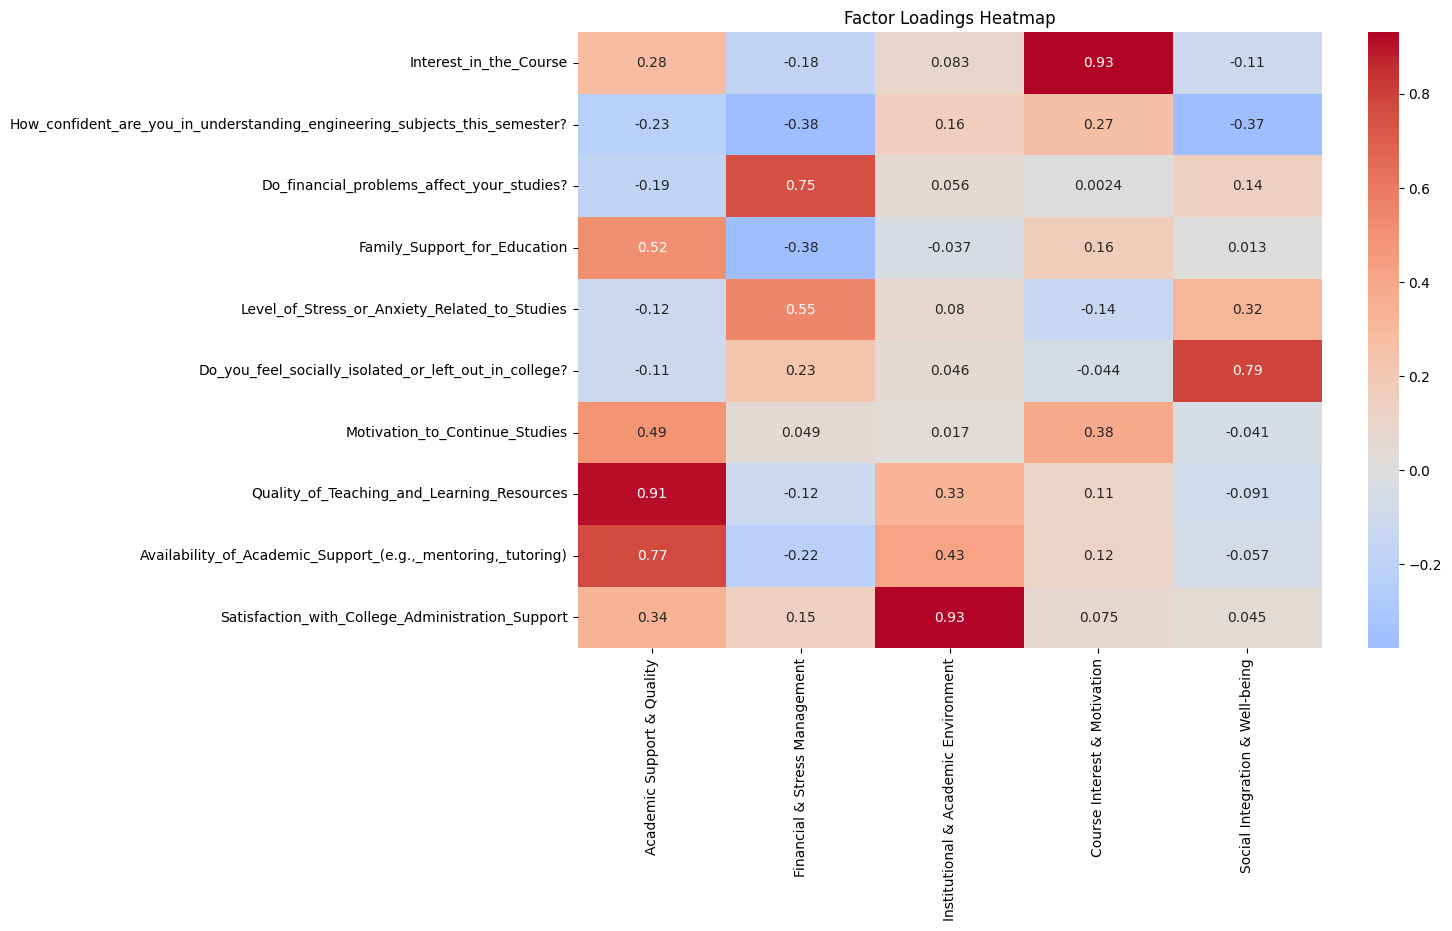

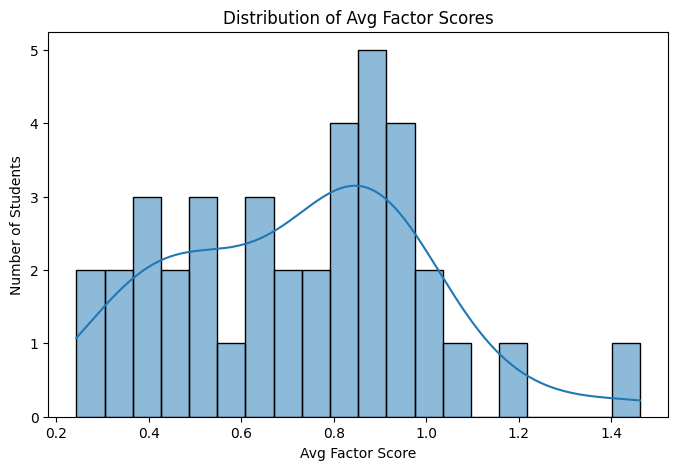

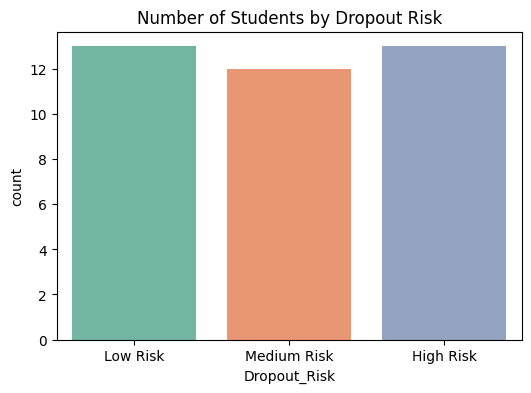

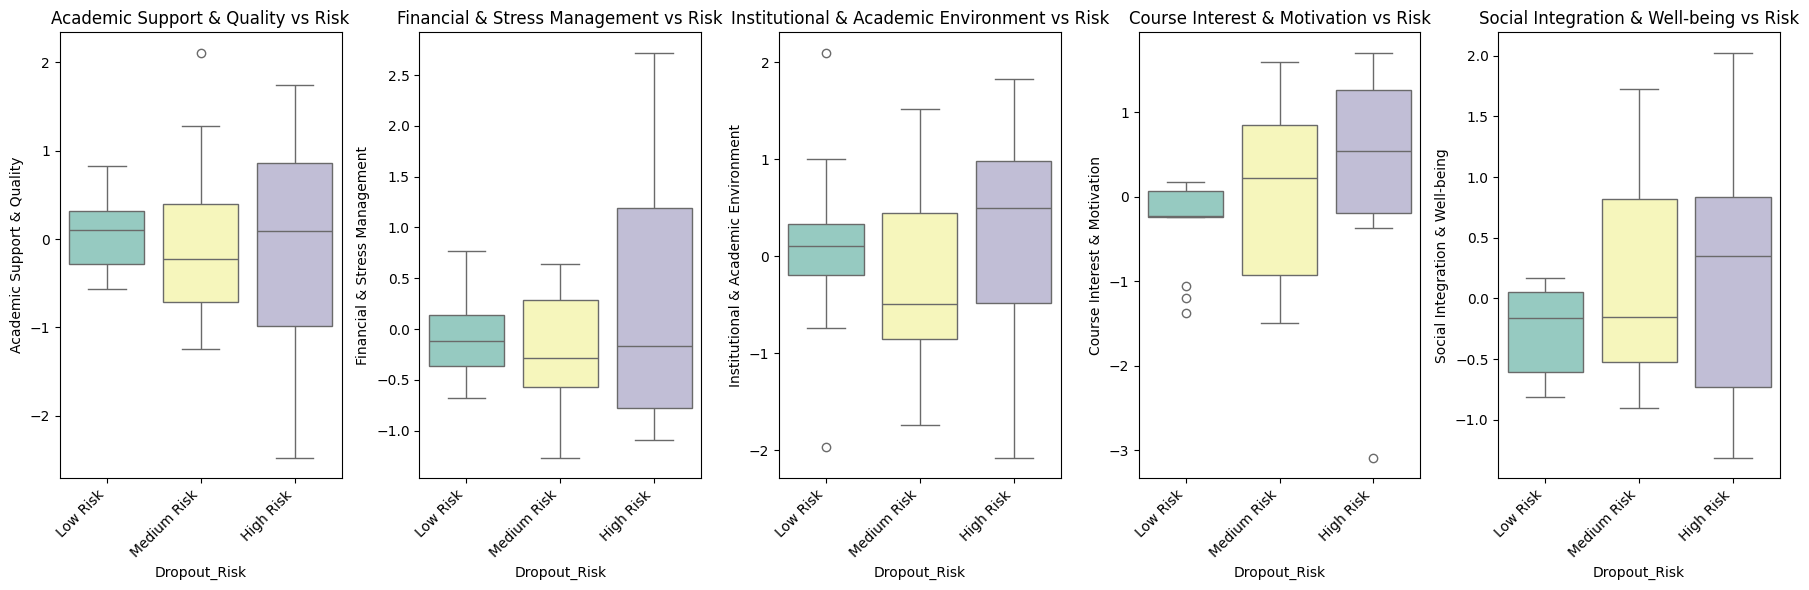

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Heatmap of factor loadings ---
plt.figure(figsize=(12,8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

# --- 2. Histogram of Average Factor Scores ---
plt.figure(figsize=(8,5))
sns.histplot(factor_scores['Avg_Factor_Score'], bins=20, kde=True)
plt.title('Distribution of Avg Factor Scores')
plt.xlabel('Avg Factor Score')
plt.ylabel('Number of Students')
plt.show()

# --- 3. Dropout Risk Counts ---
plt.figure(figsize=(6,4))
sns.countplot(x='Dropout_Risk', data=factor_scores, palette='Set2', hue='Dropout_Risk', legend=False)
plt.title('Number of Students by Dropout Risk')
plt.show()

# --- 4. Factor Scores vs Dropout Risk (Boxplot) ---
plt.figure(figsize=(18,6)) # Increased figure width for better readability with 5 factors
# Exclude 'Avg_Factor_Score' and 'Dropout_Risk' from factor columns for plotting
factor_cols_for_plot = [col for col in factor_scores.columns if col not in ['Avg_Factor_Score', 'Dropout_Risk']]
for i, factor_name in enumerate(factor_cols_for_plot):
    plt.subplot(1, len(factor_cols_for_plot), i+1)
    sns.boxplot(x='Dropout_Risk', y=factor_name, data=factor_scores, palette='Set3', hue='Dropout_Risk', legend=False)
    plt.title(f'{factor_name} vs Risk')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Confirm that the factors have been successfully renamed throughout the entire file and that all subsequent analysis and visualizations, including the factor scores and dropout risk, are now using these new, descriptive names.


## Summary:

### Data Analysis Key Findings
*   The factor names in the `loadings` DataFrame and the `variance_df` were successfully updated to new descriptive names: 'Academic Support & Quality', 'Financial & Stress Management', 'Institutional & Academic Environment', 'Course Interest & Motivation', and 'Social Integration & Well-being'.
*   The `factor_scores` DataFrame was recomputed, and its columns now accurately reflect these new descriptive factor names.
*   Dropout risk classifications ('Low Risk', 'Medium Risk', 'High Risk') were successfully reapplied to the `factor_scores` DataFrame based on the 'Avg\_Factor\_Score'.
*   All required visualizations, including the heatmap of factor loadings, histogram of average factor scores, countplot of dropout risk, and box plots of factor scores versus dropout risk, were successfully regenerated, incorporating the updated factor names and reflecting the current state of the data.

### Insights or Next Steps
*   The consistent use of descriptive factor names throughout the analysis greatly enhances the readability and interpretability of the results for stakeholders.
*   The re-calculated factor scores and updated dropout risk classifications, now linked to meaningful labels, provide a solid foundation for deeper insights into student performance and targeted intervention strategies.
